 in this tutorial we are going to train a basic regression <br>
 model that will predict Height when Weight is given as input


In [59]:
# loading the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


### Reading the dataset

In [78]:
df=pd.read_csv(r"D:\Python Projects\weight_height_prediction\SOCR-HeightWeight.csv")

In [79]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           25000 non-null  int64  
 1   Height(Inches)  25000 non-null  float64
 2   Weight(Pounds)  25000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 586.1 KB


### changing unit of weight and making all features as int

In [83]:
# creating column that contains weight in kg
df['Weight(kg)']=(df['Weight(Pounds)']*0.45359237).round().astype(int)
# creating Height(cm) from Height(Inches)
df['Height(cm)']=(df['Height(Inches)']*2.54).round().astype(int)

In [85]:
df.head(5)

,Index,Height(Inches),Weight(Pounds),Weight(kg),Height(cm)
0,1,65.78331,112.9925,51,167
1,2,71.51521,136.4873,62,182
2,3,69.39874,153.0269,69,176
3,4,68.21660,142.3354,65,173
4,5,67.78781,144.2971,65,172


In [87]:
# creating dataframe copy
df_copy=df

### droping unnecessary columns

In [88]:
df_copy.drop('Index',axis=1,inplace=True)
df_copy.drop('Weight(Pounds)',axis=1,inplace=True)
df_copy.drop('Height(Inches)',axis=1,inplace=True)

In [89]:
df_copy.head()

,Weight(kg),Height(cm)
0,51,167
1,62,182
2,69,176
3,65,173
4,65,172


In [90]:
df_copy.dtypes

Weight(kg)    int32
Height(cm)    int32
dtype: object

### Data Cleaning

In [91]:
# checking for null values
df_copy.isnull().sum()

Weight(kg)    0
Height(cm)    0
dtype: int64

In [92]:
# checking for duplicate value
df_copy.duplicated().sum()

24201

In [93]:
df_copy[df_copy.duplicated()].head(10)

,Weight(kg),Height(cm)
24,64,172
40,56,174
55,67,178
57,58,169
60,58,169
66,65,175
67,60,172
69,57,171
71,61,180
81,55,170


In [94]:
# removing duplicates
df_copy.drop_duplicates(inplace=True)

In [95]:
df_copy.shape

(799, 2)

### reset index

In [97]:
#index resetting
df_copy.reset_index(drop=True,inplace=True)

In [100]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Weight(kg)  799 non-null    int32
 1   Height(cm)  799 non-null    int32
dtypes: int32(2)
memory usage: 6.4 KB


### Distrubution Plots

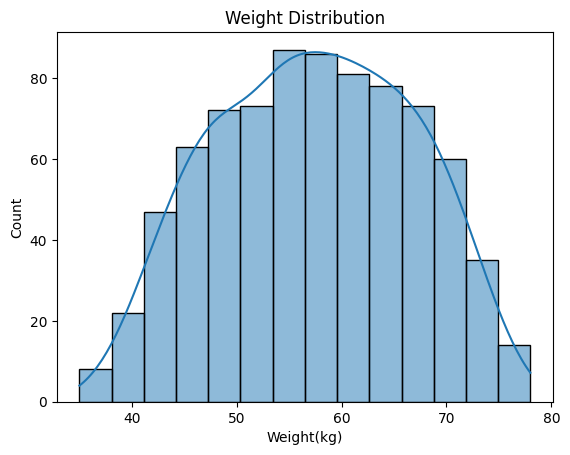

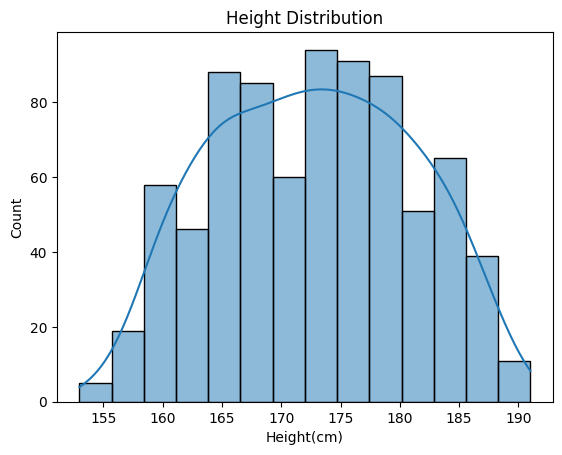

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Weight distribution
sns.histplot(df_copy['Weight(kg)'], kde=True)
plt.title('Weight Distribution')
plt.show()

# Height distribution
sns.histplot(df_copy['Height(cm)'], kde=True)
plt.title('Height Distribution')
plt.show()


### Boxplots for Outliers

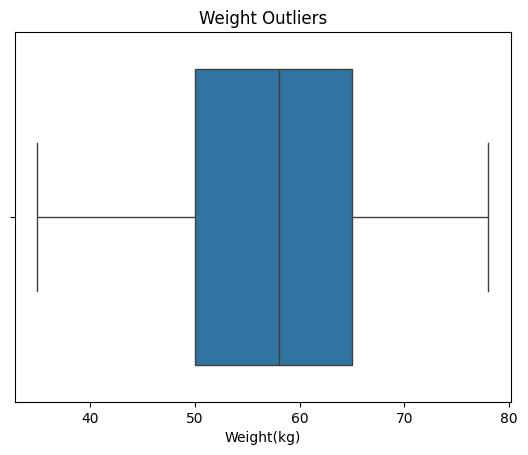

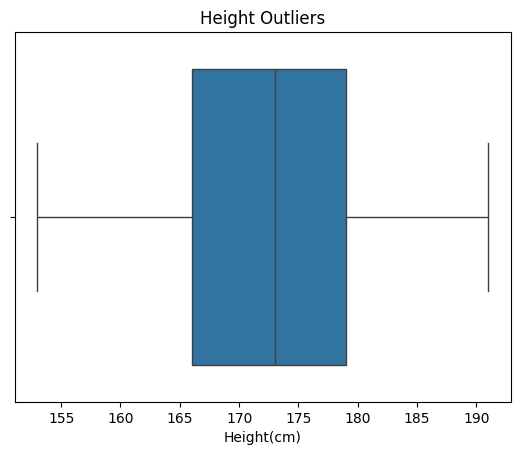

In [108]:
# Boxplot for weight
sns.boxplot(x=df_copy['Weight(kg)'])
plt.title('Weight Outliers')
plt.show()

# Boxplot for height
sns.boxplot(x=df_copy['Height(cm)'])
plt.title('Height Outliers')
plt.show()


###  Correlation Analysis

In [109]:


# Correlation
print("Correlation:", df_copy.corr())


Correlation:             Weight(kg)  Height(cm)
Weight(kg)    1.000000    0.509173
Height(cm)    0.509173    1.000000


### Dividing Features

In [110]:
# decide dependent and independent features
x=df_copy[['Weight(kg)']]
y=df_copy['Height(cm)']


### train test split

In [ ]:
from sklearn.preprocessing import train_test_split
